# Notebook 06 — Feature Analysis

## Objective

This notebook analyzes the 39 handcrafted respiratory-sound features extracted in Notebook 05.

The analysis focuses on:

- feature distributions
- descriptive statistics
- feature variance
- correlation between features
- disease-wise feature behavior
- sound-label-wise feature behavior
- feature relationships with respiratory abnormalities

This notebook performs exploratory Data Mining analysis.

No feature selection, scaling, PCA, or model training is performed here.
Those operations are handled in later notebooks.

## Important methodological principle

The disease label is patient-level, while respiratory sound labels
(crackles and wheezes) are cycle-level.

Therefore, disease-level analysis must account for the fact that
multiple respiratory cycles can originate from the same patient.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

FEATURES_DIR = (
    PROCESSED_DATA_DIR / "features"
)

print("Project root:", PROJECT_ROOT)
print("Features directory:", FEATURES_DIR)

Project root: /Users/vs/Sem 5/Respiratory-Disease-Classification
Features directory: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/features


In [2]:
features_path = (
    FEATURES_DIR /
    "respiratory_cycle_features.csv"
)

features_df = pd.read_csv(features_path)

print("Shape:", features_df.shape)
display(features_df.head())

Shape: (6898, 52)


,patient_id,recording_id,chest_location,acquisition_mode,equipment,cycle_number,start_time,end_time,sound_label,crackles,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,wavelet_energy,wavelet_entropy,wavelet_std
0,101,1b1,Al,sc,Meditron,1,0.036,0.579,Normal,0,...,14.649715,13.271879,15.322943,4.408390,9.810836,11.595978,6.332477,110.760926,0.062777,0.224449
1,101,1b1,Al,sc,Meditron,2,0.579,2.450,Normal,0,...,11.704497,17.665747,14.362599,8.428231,8.835912,10.312641,6.039036,263.467394,0.090006,0.187299
2,101,1b1,Al,sc,Meditron,3,2.450,3.893,Normal,0,...,9.776377,21.063862,10.441285,5.727220,12.893122,8.313774,3.833181,169.927915,0.150584,0.171195
3,101,1b1,Al,sc,Meditron,4,3.893,5.793,Normal,0,...,12.218080,18.453773,11.239029,5.239138,7.796915,10.357517,4.856807,189.956857,0.142102,0.157822
4,101,1b1,Al,sc,Meditron,5,5.793,7.521,Normal,0,...,11.927266,16.875360,13.980614,4.852463,6.865896,11.010699,6.107927,268.586226,0.154456,0.196740


In [3]:
metadata_columns = [
    "patient_id",
    "recording_id",
    "chest_location",
    "acquisition_mode",
    "equipment",
    "cycle_number",
    "start_time",
    "end_time",
    "sound_label",
    "crackles",
    "wheezes",
    "diagnosis",
    "processed_path",
]

feature_columns = [
    col for col in features_df.columns
    if col not in metadata_columns
]

print("Number of features:", len(feature_columns))
print("\nFeatures:")

for i, feature in enumerate(feature_columns, start=1):
    print(f"{i:02d}. {feature}")

Number of features: 39

Features:
01. mean
02. std
03. variance
04. rms
05. max
06. min
07. peak_to_peak
08. median
09. skewness
10. kurtosis
11. energy
12. zero_crossing_rate
13. spectral_centroid
14. spectral_bandwidth
15. spectral_rolloff
16. spectral_flatness
17. spectral_energy
18. dominant_frequency
19. spectral_entropy
20. band_energy_0_500
21. band_energy_500_1000
22. band_energy_1000_1500
23. band_energy_1500_2000
24. mfcc_1_mean
25. mfcc_2_mean
26. mfcc_3_mean
27. mfcc_4_mean
28. mfcc_5_mean
29. mfcc_6_mean
30. mfcc_7_mean
31. mfcc_8_mean
32. mfcc_9_mean
33. mfcc_10_mean
34. mfcc_11_mean
35. mfcc_12_mean
36. mfcc_13_mean
37. wavelet_energy
38. wavelet_entropy
39. wavelet_std


In [4]:
feature_statistics = (
    features_df[feature_columns]
    .describe()
    .T
)

feature_statistics["missing"] = (
    features_df[feature_columns]
    .isna()
    .sum()
)

feature_statistics["infinite"] = (
    np.isinf(
        features_df[feature_columns]
        .to_numpy()
    ).sum(axis=0)
)

display(feature_statistics)

,count,mean,std,min,25%,50%,75%,max,missing,infinite
mean,6898.0,-0.000585,0.027666,-2.888475e-01,-0.001839,0.000046,0.002007,4.152778e-01,0,0
std,6898.0,0.262517,0.095240,4.626528e-02,0.199937,0.253247,0.310464,8.806714e-01,0,0
variance,6898.0,0.077984,0.061152,2.140476e-03,0.039975,0.064134,0.096388,7.755821e-01,0,0
rms,6898.0,0.263801,0.095710,4.626574e-02,0.200354,0.254318,0.313063,8.888528e-01,0,0
max,6898.0,0.934378,0.115950,2.998352e-01,0.905403,0.999969,0.999969,9.999695e-01,0,0
min,6898.0,-0.927339,0.124541,-1.000000e+00,-1.000000,-0.999969,-0.896263,-2.270508e-01,0,0
peak_to_peak,6898.0,1.861717,0.139362,1.227020e+00,1.782440,1.900543,1.986412,1.999969e+00,0,0
median,6898.0,-0.000411,0.031450,-3.090210e-01,-0.006271,-0.000015,0.006496,4.241333e-01,0,0
skewness,6898.0,0.012682,0.503105,-5.220785e+00,-0.150232,0.000173,0.156095,7.292108e+00,0,0
kurtosis,6898.0,2.721379,6.623438,-1.748945e+00,0.230098,0.937983,2.506514,1.137977e+02,0,0


In [5]:
variance_df = pd.DataFrame({
    "feature": feature_columns,
    "variance": [
        features_df[col].var()
        for col in feature_columns
    ]
})

variance_df = variance_df.sort_values(
    "variance",
    ascending=False
)

display(variance_df)


,feature,variance
16,spectral_energy,3.037749e+11
36,wavelet_energy,1.067589e+06
10,energy,1.061084e+06
14,spectral_rolloff,3.428797e+04
13,spectral_bandwidth,7.023092e+03
23,mfcc_1_mean,6.561087e+03
12,spectral_centroid,5.903910e+03
24,mfcc_2_mean,6.972807e+02
25,mfcc_3_mean,3.261870e+02
17,dominant_frequency,2.383105e+02


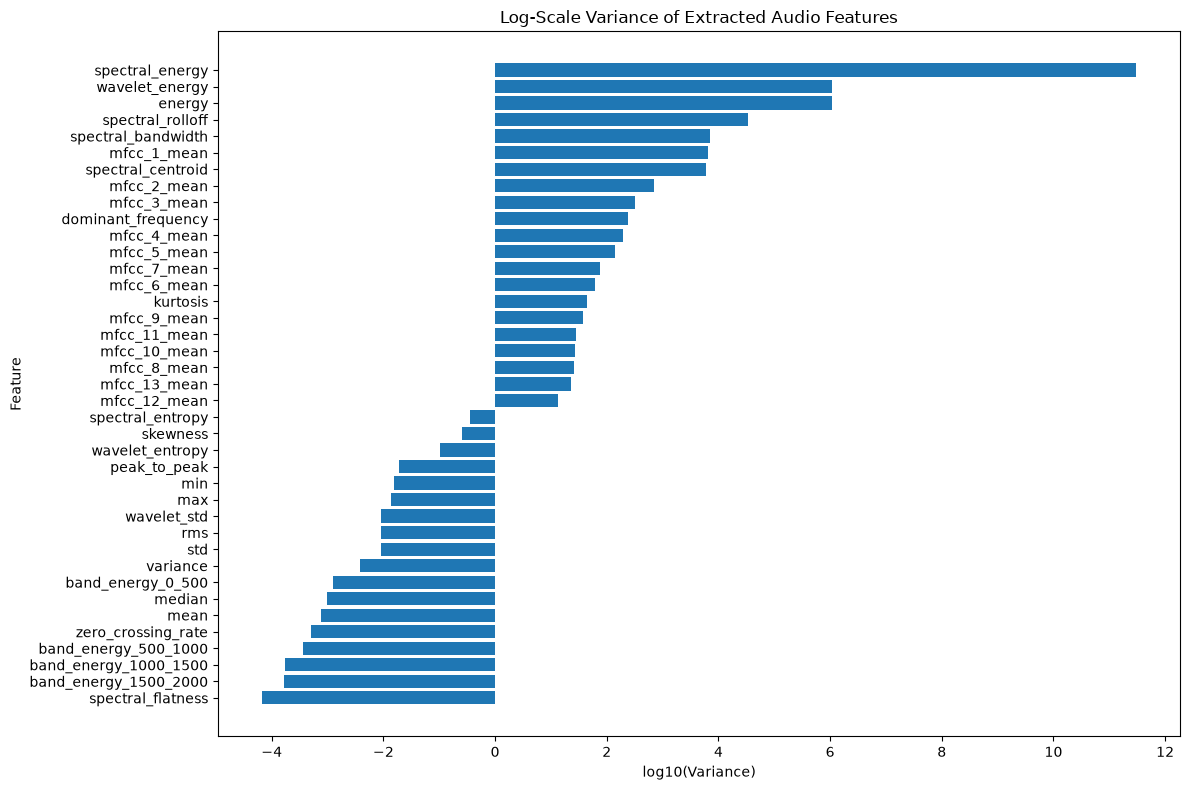

In [7]:
plt.figure(figsize=(12, 8))

plt.barh(
    variance_df["feature"],
    np.log10(variance_df["variance"] + 1e-12)
)

plt.xlabel("log10(Variance)")
plt.ylabel("Feature")
plt.title("Log-Scale Variance of Extracted Audio Features")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
cv_df = pd.DataFrame({
    "feature": feature_columns,
    "mean": [
        features_df[col].mean()
        for col in feature_columns
    ],
    "std": [
        features_df[col].std()
        for col in feature_columns
    ]
})

cv_df["coefficient_of_variation"] = (
    cv_df["std"] /
    (cv_df["mean"].abs() + 1e-12)
)

cv_df = cv_df.sort_values(
    "coefficient_of_variation",
    ascending=False
)

display(cv_df)

,feature,mean,std,coefficient_of_variation
7,median,-0.000411,0.031450,76.579635
0,mean,-0.000585,0.027666,47.313133
8,skewness,0.012682,0.503105,39.670569
22,band_energy_1500_2000,0.000734,0.012895,17.575190
21,band_energy_1000_1500,0.001313,0.013035,9.928884
20,band_energy_500_1000,0.003795,0.019123,5.038734
15,spectral_flatness,0.002332,0.008126,3.484171
9,kurtosis,2.721379,6.623438,2.433854
16,spectral_energy,369133.276500,551157.770400,1.493113
35,mfcc_13_mean,3.320271,4.760991,1.433917


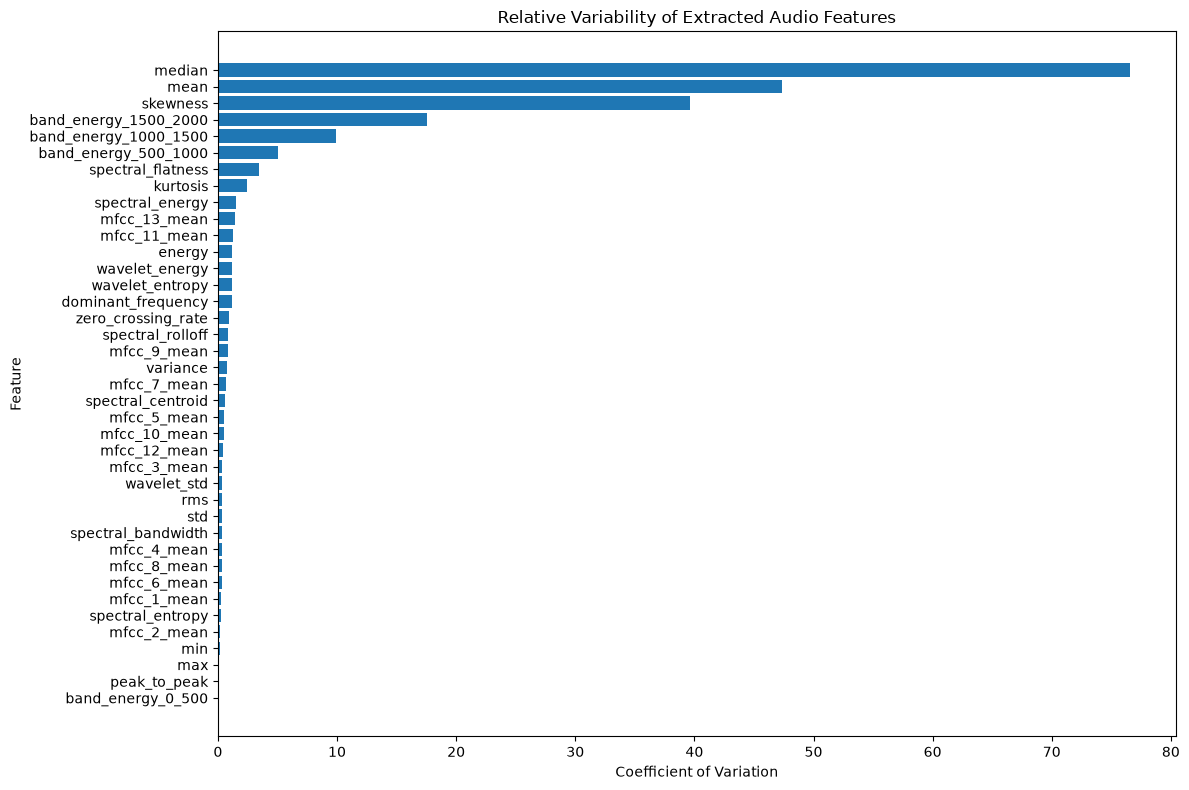

In [9]:
plt.figure(figsize=(12, 8))

plt.barh(
    cv_df["feature"],
    cv_df["coefficient_of_variation"]
)

plt.xlabel("Coefficient of Variation")
plt.ylabel("Feature")
plt.title("Relative Variability of Extracted Audio Features")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Feature Correlation Analysis
# ============================================================

correlation_matrix = (
    features_df[feature_columns]
    .corr()
)

print("Correlation matrix shape:", correlation_matrix.shape)

display(correlation_matrix)

Correlation matrix shape: (39, 39)


,mean,std,variance,rms,max,min,peak_to_peak,median,skewness,kurtosis,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,wavelet_energy,wavelet_entropy,wavelet_std
mean,1.000000,0.018692,0.025958,-0.000564,0.207378,0.136881,0.050217,0.892922,-0.043115,0.011698,...,-0.046372,0.014426,-0.014755,0.016871,0.001886,0.010533,-0.021297,0.028278,0.016788,0.001031
std,0.018692,1.000000,0.964496,0.996380,0.241924,-0.295899,0.465713,0.040952,-0.048605,-0.490321,...,-0.042294,-0.061231,0.142538,0.202508,0.221860,0.010586,0.056005,0.658910,-0.323574,0.996475
variance,0.025958,0.964496,1.000000,0.959827,0.218369,-0.256104,0.410552,0.055192,-0.035511,-0.359221,...,-0.022606,-0.048132,0.108078,0.153338,0.187972,0.006236,0.053973,0.716840,-0.256488,0.959486
rms,-0.000564,0.996380,0.959827,1.000000,0.226918,-0.289021,0.447082,0.024719,-0.048869,-0.491648,...,-0.030035,-0.064700,0.159061,0.215049,0.231544,0.000197,0.068643,0.661639,-0.330577,0.999667
max,0.207378,0.241924,0.218369,0.226918,1.000000,0.330084,0.537030,0.097437,0.485037,-0.076908,...,-0.093661,-0.046303,-0.070237,0.000465,-0.052682,0.021556,-0.093493,0.159326,0.004476,0.227620
min,0.136881,-0.295899,-0.256104,-0.289021,0.330084,1.000000,-0.619017,0.021000,0.565713,0.129687,...,0.020521,0.062448,0.004860,0.008200,0.050389,0.043207,0.083884,-0.201696,0.023519,-0.288059
peak_to_peak,0.050217,0.465713,0.410552,0.447082,0.537030,-0.619017,1.000000,0.062301,-0.101995,-0.179883,...,-0.096266,-0.094331,-0.062781,-0.006941,-0.088862,-0.020677,-0.152750,0.312807,-0.017293,0.446807
median,0.892922,0.040952,0.055192,0.024719,0.097437,0.021000,0.062301,1.000000,-0.210582,0.005142,...,-0.023885,0.001245,0.008392,0.011198,0.009892,-0.005113,-0.007623,0.105264,0.016477,0.025667
skewness,-0.043115,-0.048605,-0.035511,-0.048869,0.485037,0.565713,-0.101995,-0.210582,1.000000,0.068301,...,-0.039297,0.013916,-0.045509,-0.010304,-0.007870,0.026575,-0.008222,-0.033913,0.025916,-0.048276
kurtosis,0.011698,-0.490321,-0.359221,-0.491648,-0.076908,0.129687,-0.179883,0.005142,0.068301,1.000000,...,0.148845,0.028505,-0.060787,-0.216143,-0.081037,-0.069179,0.070804,-0.236636,0.213136,-0.492054


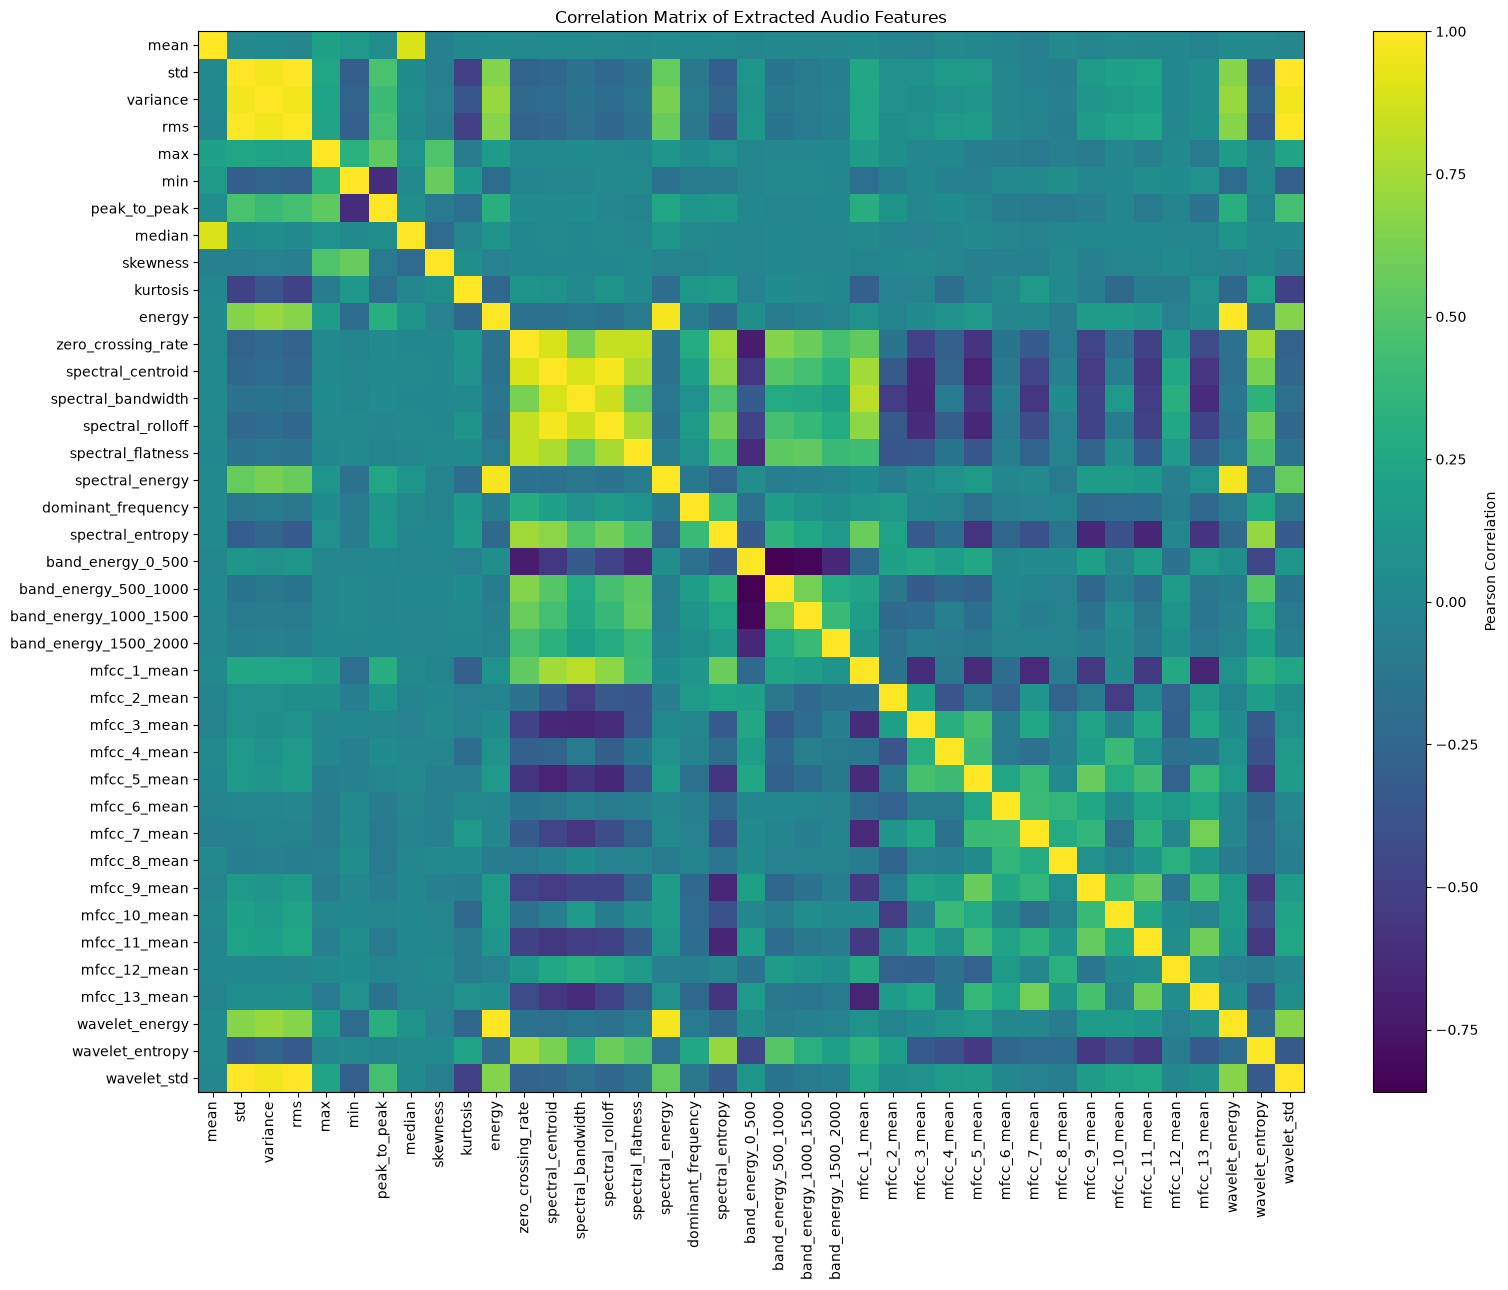

In [11]:
plt.figure(figsize=(16, 13))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.title("Correlation Matrix of Extracted Audio Features")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Highly Correlated Feature Pairs
# ============================================================

correlation_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):

        feature_1 = feature_columns[i]
        feature_2 = feature_columns[j]

        correlation = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        if abs(correlation) >= 0.90:

            correlation_pairs.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "correlation": correlation,
                "absolute_correlation": abs(correlation)
            })

high_correlation_df = pd.DataFrame(
    correlation_pairs
)

if len(high_correlation_df) > 0:

    high_correlation_df = (
        high_correlation_df
        .sort_values(
            "absolute_correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

print(
    "Number of highly correlated pairs:",
    len(high_correlation_df)
)

display(high_correlation_df)

Number of highly correlated pairs: 10


,feature_1,feature_2,correlation,absolute_correlation
0,energy,wavelet_energy,0.999941,0.999941
1,rms,wavelet_std,0.999667,0.999667
2,std,wavelet_std,0.996475,0.996475
3,std,rms,0.996380,0.996380
4,energy,spectral_energy,0.976886,0.976886
5,spectral_energy,wavelet_energy,0.976468,0.976468
6,spectral_centroid,spectral_rolloff,0.974991,0.974991
7,std,variance,0.964496,0.964496
8,variance,rms,0.959827,0.959827
9,variance,wavelet_std,0.959486,0.959486


In [13]:
very_high_correlation_df = (
    high_correlation_df[
        high_correlation_df["absolute_correlation"] >= 0.95
    ]
    .reset_index(drop=True)
)

print(
    "Pairs with |correlation| >= 0.95:",
    len(very_high_correlation_df)
)

display(very_high_correlation_df)

Pairs with |correlation| >= 0.95: 10


,feature_1,feature_2,correlation,absolute_correlation
0,energy,wavelet_energy,0.999941,0.999941
1,rms,wavelet_std,0.999667,0.999667
2,std,wavelet_std,0.996475,0.996475
3,std,rms,0.996380,0.996380
4,energy,spectral_energy,0.976886,0.976886
5,spectral_energy,wavelet_energy,0.976468,0.976468
6,spectral_centroid,spectral_rolloff,0.974991,0.974991
7,std,variance,0.964496,0.964496
8,variance,rms,0.959827,0.959827
9,variance,wavelet_std,0.959486,0.959486


In [14]:
print("Disease distribution:")
display(
    features_df["diagnosis"]
    .value_counts()
)

Disease distribution:


diagnosis
COPD              5746
Healthy            322
Pneumonia          285
URTI               243
Bronchiolitis      160
Bronchiectasis     104
LRTI                32
Asthma               6
Name: count, dtype: int64

In [15]:
# ============================================================
# Disease-wise Feature Means
# ============================================================

disease_feature_means = (
    features_df
    .groupby("diagnosis")[feature_columns]
    .mean()
)

display(disease_feature_means)

,mean,std,variance,rms,max,min,peak_to_peak,median,skewness,kurtosis,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,wavelet_energy,wavelet_entropy,wavelet_std
diagnosis,,,,,,,,,,,,,,,,,,,,,
Asthma,-0.000367,0.282073,0.079928,0.282078,0.923447,-0.942317,1.865763,-0.002363,0.014530,0.691638,...,19.346368,18.158178,15.509195,12.940685,13.282827,15.690436,10.419955,1062.753679,0.005373,0.283210
Bronchiectasis,-0.000322,0.164635,0.029110,0.164637,0.915706,-0.919297,1.835003,-0.001071,0.048246,5.999748,...,7.259261,14.822078,3.933279,10.530230,0.955892,6.967989,2.184892,345.445246,0.606245,0.164950
Bronchiolitis,0.000955,0.244288,0.063229,0.244707,0.924735,-0.876745,1.801480,-0.004074,0.172470,1.816257,...,7.974218,17.809624,7.530293,9.985529,7.926257,7.507073,5.444566,389.639687,0.279850,0.246290
COPD,-0.000756,0.264446,0.079790,0.265942,0.936853,-0.939348,1.876201,-0.000160,-0.007685,2.891889,...,12.470933,15.425231,7.130742,9.629812,3.438958,8.326481,2.745041,915.542385,0.293645,0.266653
Healthy,0.000361,0.255730,0.069877,0.255913,0.935818,-0.835186,1.771004,-0.003260,0.169110,1.620056,...,13.726034,18.796623,10.131435,12.521751,9.474645,10.766543,7.731561,541.812398,0.070488,0.257135
LRTI,0.004043,0.311231,0.100127,0.312654,0.928900,-0.863286,1.792186,0.004246,0.031622,0.418956,...,11.843573,18.393766,9.272860,13.180099,11.989380,8.907039,7.193138,433.919377,0.053056,0.315067
Pneumonia,0.000020,0.282686,0.084471,0.282836,0.909678,-0.918801,1.828479,0.002774,-0.008514,0.930336,...,17.289195,15.016521,10.914651,10.426644,8.253916,8.541009,6.544302,819.925607,0.086428,0.284171
URTI,-0.000231,0.249234,0.066097,0.249418,0.918241,-0.820327,1.738568,-0.004164,0.188887,1.795630,...,11.508465,16.584420,10.444675,11.852637,9.319567,10.862877,5.697408,485.071700,0.155350,0.250681


In [16]:
# ============================================================
# Standardized Disease Feature Profiles
# ============================================================

feature_means = (
    features_df[feature_columns].mean()
)

feature_stds = (
    features_df[feature_columns]
    .std()
    .replace(0, 1)
)

standardized_features = (
    features_df[feature_columns] -
    feature_means
) / feature_stds

standardized_features["diagnosis"] = (
    features_df["diagnosis"].values
)

disease_zmeans = (
    standardized_features
    .groupby("diagnosis")[feature_columns]
    .mean()
)

display(disease_zmeans)

,mean,std,variance,rms,max,min,peak_to_peak,median,skewness,kurtosis,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,wavelet_energy,wavelet_entropy,wavelet_std
diagnosis,,,,,,,,,,,,,,,,,,,,,
Asthma,0.007861,0.205335,0.031779,0.190964,-0.094278,-0.120261,0.029031,-0.062063,0.003673,-0.306448,...,0.778208,0.490439,1.310592,0.577735,1.698735,1.979361,1.491220,0.200023,-0.829399,0.193729
Bronchiectasis,0.009508,-1.027734,-0.799222,-1.036078,-0.161033,0.064577,-0.191690,-0.020997,0.070690,0.494965,...,-0.598693,-0.166846,-0.588904,0.117138,-0.617364,-0.424472,-0.238475,-0.494208,1.034000,-1.037533
Bronchiolitis,0.055655,-0.191399,-0.241294,-0.199495,-0.083164,0.406249,-0.432239,-0.116490,0.317605,-0.136654,...,-0.517249,0.421766,0.001331,0.013054,0.692293,-0.275905,0.446188,-0.451436,0.021800,-0.190663
COPD,-0.006203,0.020256,0.029524,0.022374,0.021348,-0.096424,0.103931,0.007965,-0.040483,0.025744,...,-0.005006,-0.048012,-0.064231,-0.054917,-0.150822,-0.050083,-0.120821,0.057548,0.064579,0.021342
Healthy,0.034182,-0.071263,-0.132585,-0.082409,0.012419,0.739947,-0.650921,-0.090590,0.310926,-0.166277,...,0.137968,0.616227,0.428154,0.497684,0.983219,0.622378,0.926549,-0.304159,-0.627467,-0.077750
LRTI,0.167259,0.511484,0.362092,0.510424,-0.047248,0.514316,-0.498929,0.148073,0.037646,-0.347617,...,-0.076472,0.536855,0.287270,0.623483,1.455711,0.109914,0.813458,-0.408580,-0.681525,0.525405
Pneumonia,0.021868,0.211772,0.106081,0.198880,-0.213024,0.068557,-0.238504,0.101263,-0.042131,-0.270410,...,0.543865,-0.128537,0.556672,0.097344,0.753857,0.009040,0.677177,-0.034993,-0.578033,0.203729
URTI,0.012790,-0.139461,-0.194384,-0.150276,-0.139177,0.859254,-0.883671,-0.119339,0.350235,-0.139769,...,-0.114646,0.180374,0.479553,0.369828,0.954081,0.648927,0.499295,-0.359074,-0.364296,-0.144946


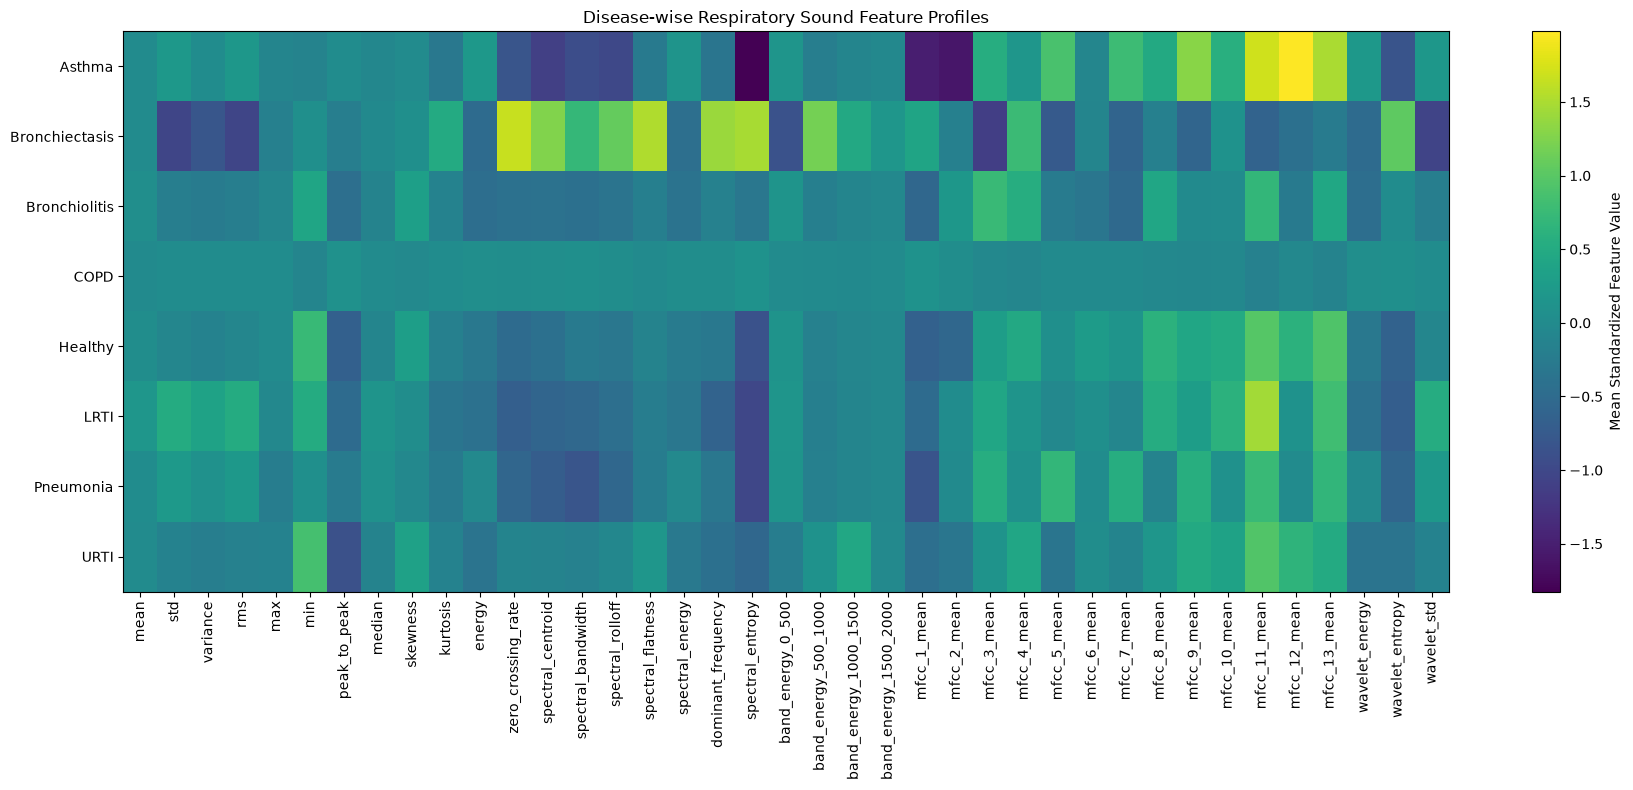

In [17]:
plt.figure(figsize=(18, 8))

plt.imshow(
    disease_zmeans,
    aspect="auto"
)

plt.colorbar(
    label="Mean Standardized Feature Value"
)

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(disease_zmeans)),
    disease_zmeans.index
)

plt.title(
    "Disease-wise Respiratory Sound Feature Profiles"
)

plt.tight_layout()
plt.show()

In [18]:
print("Sound-label distribution:")

display(
    features_df["sound_label"]
    .value_counts()
)

Sound-label distribution:


sound_label
Normal      3642
Crackles    1864
Wheezes      886
Both         506
Name: count, dtype: int64

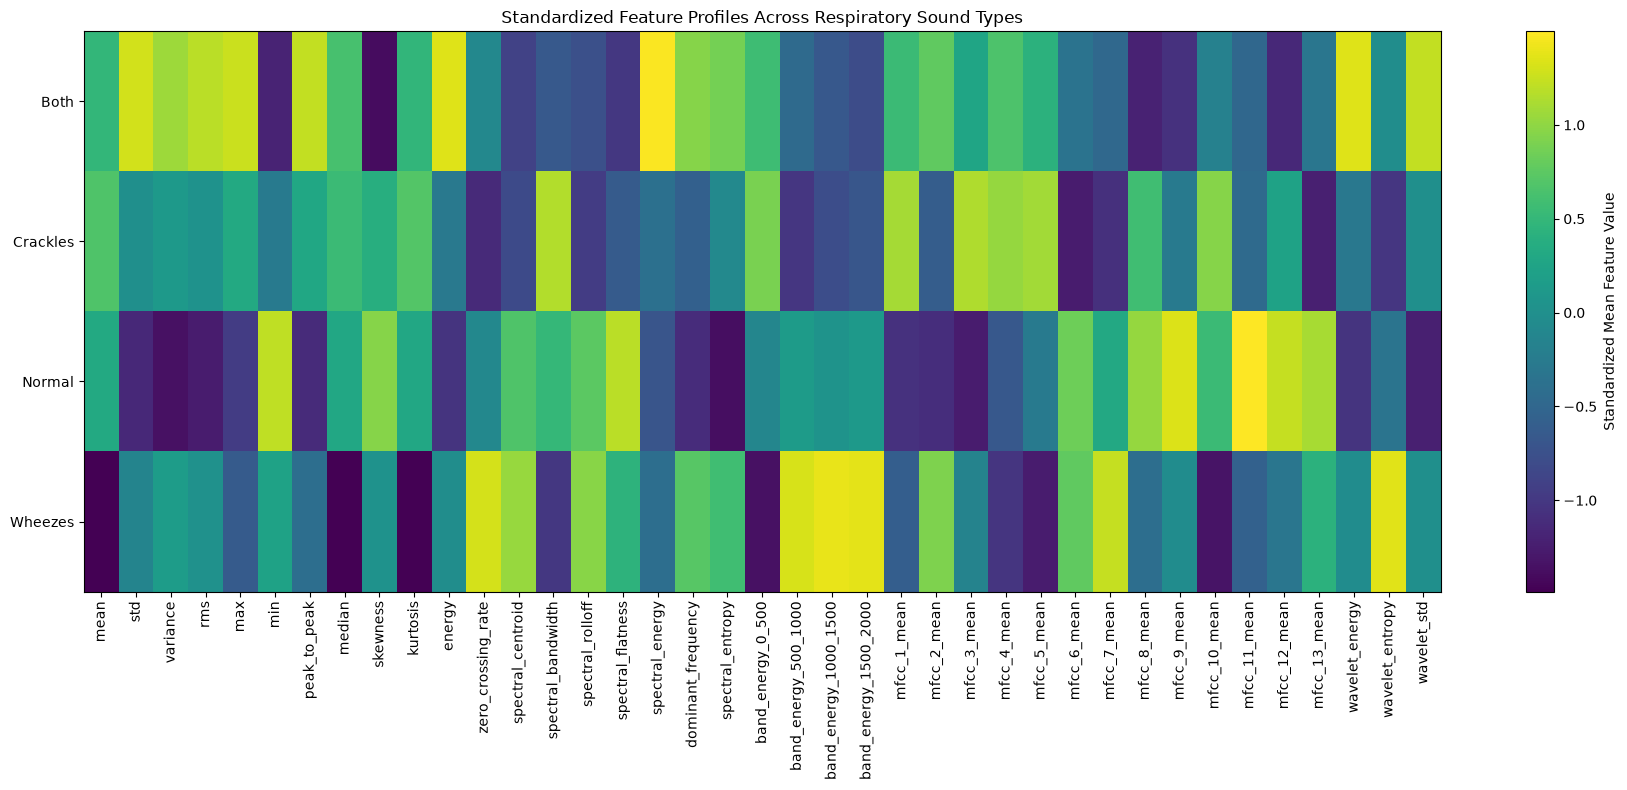

In [21]:
# ============================================================
# Standardized Sound-label Feature Profiles
# ============================================================

sound_means = (
    features_df
    .groupby("sound_label")[feature_columns]
    .mean()
)

# Standardize each feature across sound categories
sound_zmeans = (
    sound_means - sound_means.mean(axis=0)
) / (
    sound_means.std(axis=0).replace(0, 1)
)

plt.figure(figsize=(18, 8))

plt.imshow(
    sound_zmeans,
    aspect="auto"
)

plt.colorbar(
    label="Standardized Mean Feature Value"
)

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(sound_zmeans)),
    sound_zmeans.index
)

plt.title(
    "Standardized Feature Profiles Across Respiratory Sound Types"
)

plt.tight_layout()
plt.show()

In [22]:
crackle_feature_means = (
    features_df
    .groupby("crackles")[feature_columns]
    .mean()
)

display(crackle_feature_means)

,mean,std,variance,rms,max,min,peak_to_peak,median,skewness,kurtosis,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,wavelet_energy,wavelet_entropy,wavelet_std
crackles,,,,,,,,,,,,,,,,,,,,,
0,-0.000978,0.261526,0.077228,0.262978,0.929177,-0.919892,1.849069,-0.000754,0.018295,2.708412,...,12.997100,15.811866,7.785700,9.736416,4.618295,8.697258,3.863377,835.783404,0.291579,0.263824
1,0.000167,0.264410,0.079430,0.265373,0.944316,-0.941567,1.885883,0.000245,0.001959,2.746152,...,11.593579,15.395811,7.018708,10.262629,3.522127,8.147021,2.282639,894.862743,0.236983,0.266091


In [23]:
wheeze_feature_means = (
    features_df
    .groupby("wheezes")[feature_columns]
    .mean()
)

display(wheeze_feature_means)

,mean,std,variance,rms,max,min,peak_to_peak,median,skewness,kurtosis,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,wavelet_energy,wavelet_entropy,wavelet_std
wheezes,,,,,,,,,,,,,,,,,,,,,
0,-0.000165,0.261976,0.077552,0.263326,0.933148,-0.924405,1.857553,-0.000044,0.018044,2.734487,...,12.364470,15.911114,7.647221,10.232475,4.436192,8.677065,3.344751,839.498390,0.253131,0.264140
1,-0.002245,0.264655,0.079696,0.265680,0.939245,-0.938947,1.878192,-0.001861,-0.008525,2.669528,...,13.109827,14.710924,7.027579,8.670199,3.472277,7.840304,3.223440,921.676594,0.350702,0.266435


In [24]:
crackle_correlations = (
    features_df[
        feature_columns + ["crackles"]
    ]
    .corr()["crackles"]
    .drop("crackles")
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

print("Feature correlation with crackles:")
display(crackle_correlations)

Feature correlation with crackles:


mfcc_13_mean            -0.157688
mfcc_4_mean              0.128202
peak_to_peak             0.125457
mfcc_6_mean             -0.109783
mfcc_11_mean            -0.097817
band_energy_500_1000    -0.082949
min                     -0.082655
wavelet_entropy         -0.080411
spectral_flatness       -0.078568
mfcc_7_mean             -0.075934
band_energy_0_500        0.073498
spectral_entropy         0.072320
mfcc_12_mean            -0.072020
spectral_rolloff        -0.069641
mfcc_1_mean              0.064899
zero_crossing_rate      -0.062056
max                      0.062010
mfcc_9_mean             -0.059774
mfcc_3_mean              0.056857
mfcc_5_mean              0.056210
mfcc_10_mean             0.047755
band_energy_1000_1500   -0.047556
spectral_centroid       -0.039090
mfcc_2_mean              0.038986
mfcc_8_mean             -0.038931
dominant_frequency       0.035263
band_energy_1500_2000   -0.032439
energy                   0.027248
wavelet_energy           0.027156
spectral_bandw

In [25]:
wheeze_correlations = (
    features_df[
        feature_columns + ["wheezes"]
    ]
    .corr()["wheezes"]
    .drop("wheezes")
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

print("Feature correlation with wheezes:")
display(wheeze_correlations)

Feature correlation with wheezes:


mfcc_2_mean              0.153239
wavelet_entropy          0.121447
mfcc_10_mean            -0.119819
dominant_frequency       0.102599
mfcc_8_mean             -0.094910
mfcc_12_mean            -0.092558
spectral_entropy         0.088886
mfcc_11_mean            -0.072692
spectral_bandwidth      -0.060421
zero_crossing_rate       0.059809
peak_to_peak             0.059442
band_energy_500_1000     0.050225
min                     -0.046867
band_energy_0_500       -0.045742
mfcc_9_mean             -0.040810
mfcc_7_mean              0.034079
band_energy_1000_1500    0.032866
wavelet_energy           0.031923
energy                   0.031903
mean                    -0.030175
mfcc_5_mean             -0.028421
spectral_flatness       -0.024892
median                  -0.023196
skewness                -0.021196
max                      0.021105
mfcc_4_mean             -0.020419
band_energy_1500_2000    0.018958
spectral_energy          0.016254
variance                 0.014076
mfcc_6_mean   

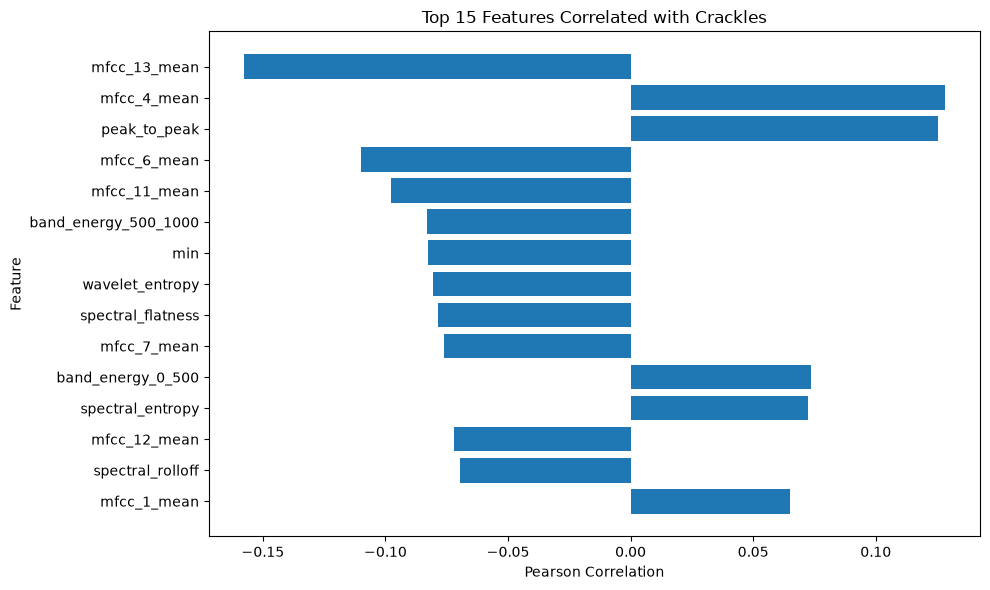

In [26]:
top_crackle_correlations = (
    crackle_correlations
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_crackle_correlations.index[::-1],
    top_crackle_correlations.values[::-1]
)

plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features Correlated with Crackles"
)

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# Feature Correlation with Wheezes
# ============================================================

wheeze_correlations = (
    features_df[
        feature_columns + ["wheezes"]
    ]
    .corr()["wheezes"]
    .drop("wheezes")
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

print("Feature correlation with wheezes:")
display(wheeze_correlations)

Feature correlation with wheezes:


mfcc_2_mean              0.153239
wavelet_entropy          0.121447
mfcc_10_mean            -0.119819
dominant_frequency       0.102599
mfcc_8_mean             -0.094910
mfcc_12_mean            -0.092558
spectral_entropy         0.088886
mfcc_11_mean            -0.072692
spectral_bandwidth      -0.060421
zero_crossing_rate       0.059809
peak_to_peak             0.059442
band_energy_500_1000     0.050225
min                     -0.046867
band_energy_0_500       -0.045742
mfcc_9_mean             -0.040810
mfcc_7_mean              0.034079
band_energy_1000_1500    0.032866
wavelet_energy           0.031923
energy                   0.031903
mean                    -0.030175
mfcc_5_mean             -0.028421
spectral_flatness       -0.024892
median                  -0.023196
skewness                -0.021196
max                      0.021105
mfcc_4_mean             -0.020419
band_energy_1500_2000    0.018958
spectral_energy          0.016254
variance                 0.014076
mfcc_6_mean   

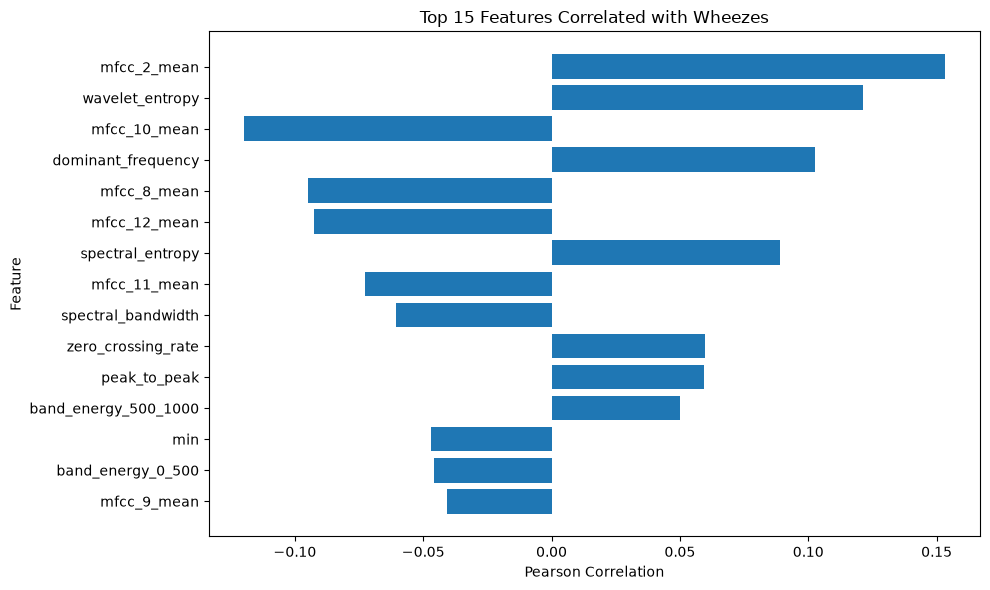

In [28]:
top_wheeze_correlations = (
    wheeze_correlations
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_wheeze_correlations.index[::-1],
    top_wheeze_correlations.values[::-1]
)

plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features Correlated with Wheezes"
)

plt.tight_layout()
plt.show()

In [29]:
selected_visual_features = [
    "rms",
    "zero_crossing_rate",
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_entropy",
    "mfcc_1_mean"
]

print("Selected visualization features:")

for feature in selected_visual_features:
    print("-", feature)

Selected visualization features:
- rms
- zero_crossing_rate
- spectral_centroid
- spectral_bandwidth
- spectral_entropy
- mfcc_1_mean


<Figure size 900x500 with 0 Axes>

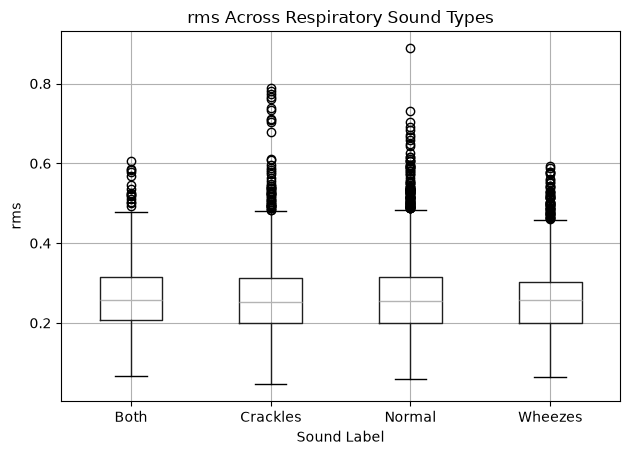

<Figure size 900x500 with 0 Axes>

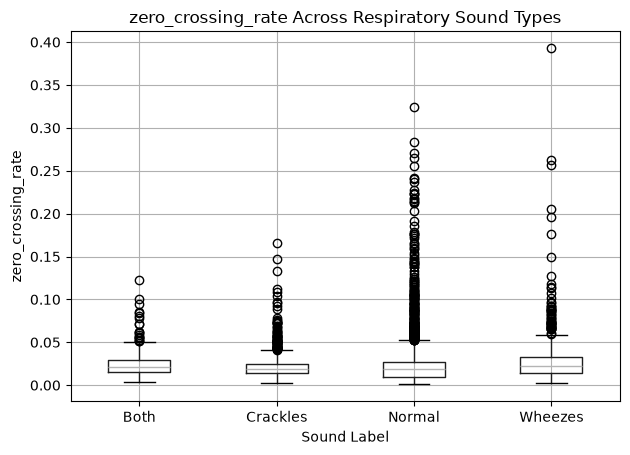

<Figure size 900x500 with 0 Axes>

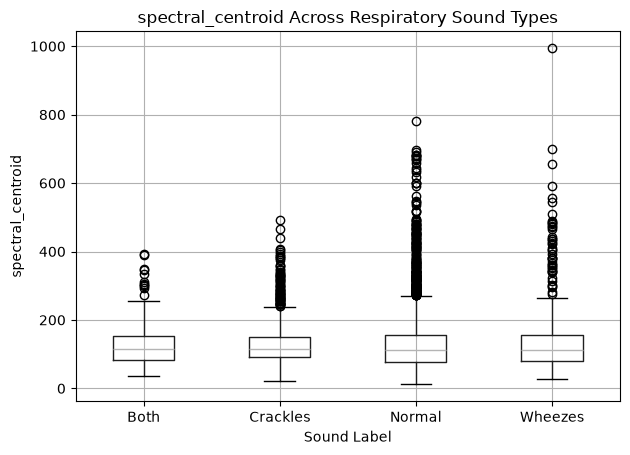

<Figure size 900x500 with 0 Axes>

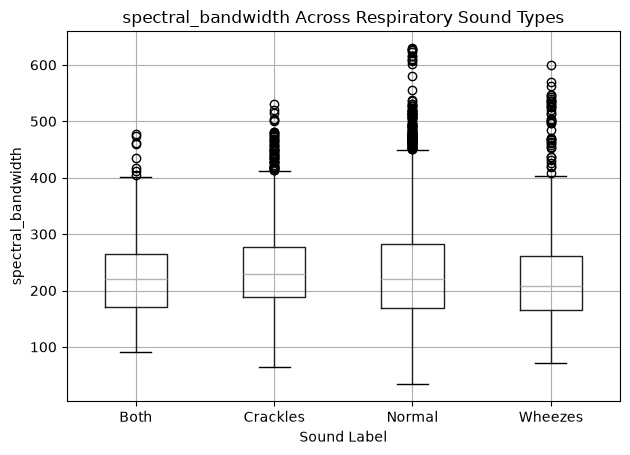

<Figure size 900x500 with 0 Axes>

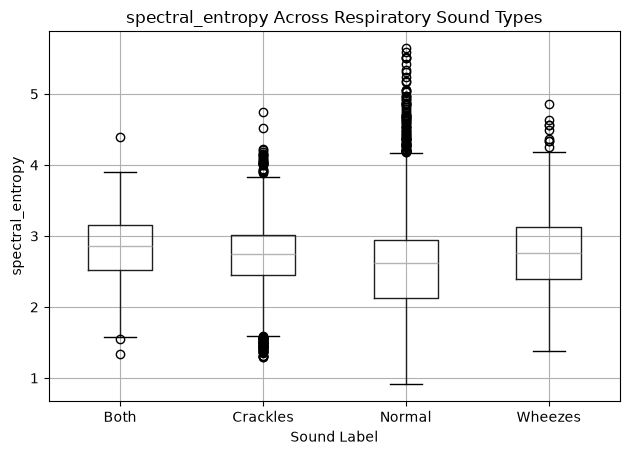

<Figure size 900x500 with 0 Axes>

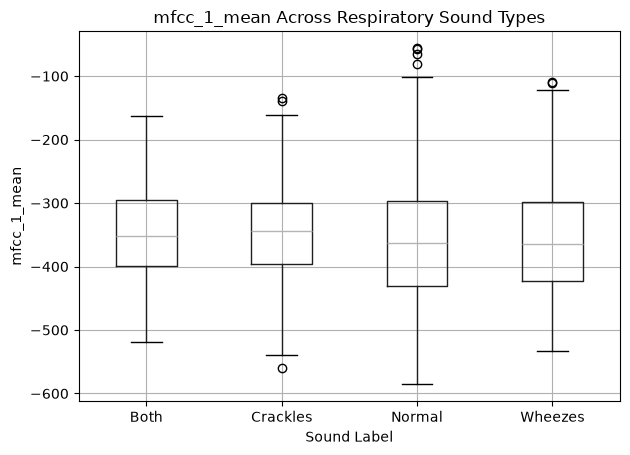

In [30]:
for feature in selected_visual_features:

    plt.figure(figsize=(9, 5))

    features_df.boxplot(
        column=feature,
        by="sound_label"
    )

    plt.title(
        f"{feature} Across Respiratory Sound Types"
    )

    plt.suptitle("")

    plt.xlabel("Sound Label")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

In [31]:
ANALYSIS_DIR = (
    PROCESSED_DATA_DIR / "analysis"
)

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [32]:
# ============================================================
# Save Feature Analysis Results
# ============================================================

feature_statistics.to_csv(
    ANALYSIS_DIR / "feature_statistics.csv"
)

variance_df.to_csv(
    ANALYSIS_DIR / "feature_variance.csv",
    index=False
)

cv_df.to_csv(
    ANALYSIS_DIR / "feature_coefficient_variation.csv",
    index=False
)

high_correlation_df.to_csv(
    ANALYSIS_DIR / "high_correlation_pairs.csv",
    index=False
)

very_high_correlation_df.to_csv(
    ANALYSIS_DIR / "very_high_correlation_pairs.csv",
    index=False
)

disease_feature_means.to_csv(
    ANALYSIS_DIR / "disease_feature_means.csv"
)

sound_feature_means.to_csv(
    ANALYSIS_DIR / "sound_feature_means.csv"
)

crackle_feature_means.to_csv(
    ANALYSIS_DIR / "crackle_feature_means.csv"
)

wheeze_feature_means.to_csv(
    ANALYSIS_DIR / "wheeze_feature_means.csv"
)

crackle_correlations.to_csv(
    ANALYSIS_DIR / "crackle_feature_correlations.csv"
)

wheeze_correlations.to_csv(
    ANALYSIS_DIR / "wheeze_feature_correlations.csv"
)

print("All Notebook 06 analysis tables saved.")
print("Output directory:")
print(ANALYSIS_DIR)

All Notebook 06 analysis tables saved.
Output directory:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/analysis


In [33]:
# ============================================================
# Notebook 06 Final Validation
# ============================================================

print("========== NOTEBOOK 06 VALIDATION ==========")

print("Feature dataset shape:", features_df.shape)
print("Number of features:", len(feature_columns))

print(
    "Missing feature values:",
    features_df[feature_columns].isna().sum().sum()
)

print(
    "Infinite feature values:",
    np.isinf(
        features_df[feature_columns].to_numpy()
    ).sum()
)

print(
    "Highly correlated pairs (|r| >= 0.90):",
    len(high_correlation_df)
)

print(
    "Very highly correlated pairs (|r| >= 0.95):",
    len(very_high_correlation_df)
)

print(
    "Disease classes:",
    features_df["diagnosis"].nunique()
)

print(
    "Sound classes:",
    features_df["sound_label"].nunique()
)

print("\nDisease classes:")
print(
    features_df["diagnosis"]
    .unique()
)

print("\nSound classes:")
print(
    features_df["sound_label"]
    .unique()
)

print("\nNotebook 06 analysis complete.")

========== NOTEBOOK 06 VALIDATION ==========
Feature dataset shape: (6898, 52)
Number of features: 39
Missing feature values: 0
Infinite feature values: 0
Highly correlated pairs (|r| >= 0.90): 10
Very highly correlated pairs (|r| >= 0.95): 10
Disease classes: 8
Sound classes: 4

Disease classes:
<StringArray>
[          'URTI',        'Healthy',         'Asthma',           'COPD',
           'LRTI', 'Bronchiectasis',      'Pneumonia',  'Bronchiolitis']
Length: 8, dtype: str

Sound classes:
<StringArray>
['Normal', 'Wheezes', 'Crackles', 'Both']
Length: 4, dtype: str

Notebook 06 analysis complete.


# Notebook 06 — Feature Analysis: Final Validation

## Summary

The feature analysis stage was completed successfully on the respiratory-cycle dataset.

### Dataset Validation

- Feature dataset shape: **6,898 cycles × 52 columns**
- Handcrafted audio features analyzed: **39**
- Missing feature values: **0**
- Infinite feature values: **0**

### Classification Targets

The dataset contains:

- **8 disease classes**
  - URTI
  - Healthy
  - Asthma
  - COPD
  - LRTI
  - Bronchiectasis
  - Pneumonia
  - Bronchiolitis

- **4 respiratory sound classes**
  - Normal
  - Wheezes
  - Crackles
  - Both

### Data Mining Analysis Performed

The following exploratory Data Mining analyses were completed:

1. Descriptive statistics of all 39 features
2. Feature variance and relative variability analysis
3. Pearson correlation analysis
4. Highly correlated feature-pair identification
5. Disease-wise feature analysis
6. Respiratory sound-wise feature analysis
7. Crackle-associated feature analysis
8. Wheeze-associated feature analysis
9. Feature distribution analysis using boxplots

### Correlation Analysis

- Highly correlated feature pairs with **|r| ≥ 0.90**: **10**
- Very highly correlated feature pairs with **|r| ≥ 0.95**: **10**

These correlated features will be considered during the feature-selection stage to reduce redundancy.

### Important Methodological Note

The analysis performed in this notebook is exploratory. Features have **not been removed or permanently selected** based only on these observations.

Feature selection will be performed systematically in **Notebook 07** using multiple Data Mining and machine-learning-based approaches, including correlation filtering, ANOVA, Mutual Information, and Random Forest feature importance.

Scaling, feature selection, and dimensionality reduction will also be handled carefully with respect to the training data to prevent data leakage.

## Conclusion

Notebook 06 successfully established the statistical structure, relationships, redundancy, and class-wise behavior of the 39 handcrafted respiratory-sound features.

**Notebook 06 analysis complete.**